### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

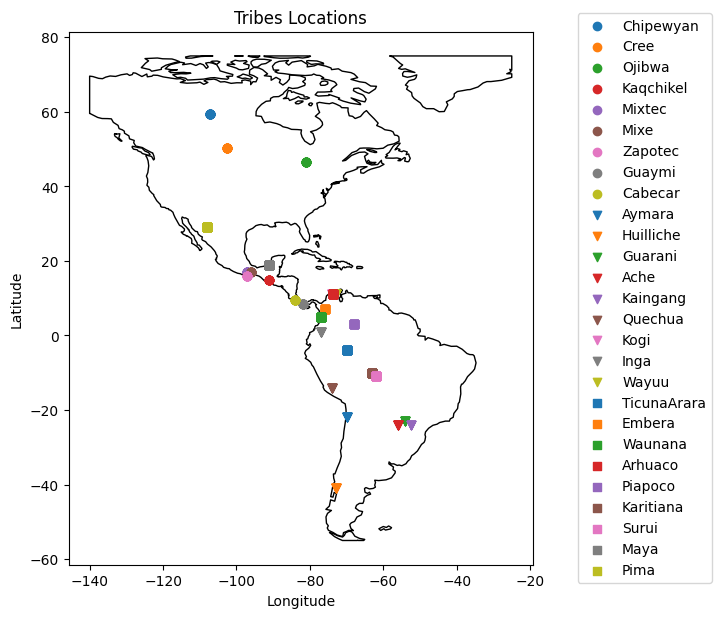

In [3]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')
df_copy = df.copy()

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

It begins by loading a global base map, clipped to the specific coordinates of the Americas, to serve as a visual background. The code loop through each unique population and plot the latitude and longitude of each population with a different markers.

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$.

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [4]:
import numpy as np

predictors = df.columns[8:]
X = df[predictors].to_numpy(dtype=float)
y = df['long'].to_numpy(dtype=float)

XtX = X.T @ X
Xty = X.T @ y

beta = np.linalg.solve(XtX, Xty)

LinAlgError: Singular matrix

We have $rg(X^T X) = rg(X) \lt p$ and $X^T X \in \mathbb{M}(\mathbb{R})^{p \times p}$. Then the matrix $X^T X$ is singular (not inversible).

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result).

And now? Did you get any errors? Why is that?

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [5]:
result = np.linalg.lstsq(X, y, rcond=None)
beta = result[0]

`numpy.linalg.lstsq` function is specifically designed to handle singular or rectangular matrices because it only compute an approximation without inverting the matrix. It computes the least-squares approximation, finding the coefficients $\beta$​ that minimize the squared error $\lVert y - \beta X \rVert ^2 $

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model.

In [6]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
print("Coefficients (sklearn):", lr.coef_)
print("Coefficients (numpy):", beta)

Coefficients (sklearn): [-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]
Coefficients (numpy): [-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


In multiple linear regression model, the equation is $ y = \sum_{i = 1}^N \beta_i x_i + \beta_0$. The intercept $\beta_0$ respresent the expected value when all the predictor are zero. In the real world a value of 0 for all feature is biologically impossible. The intercept has no practical meaning. To center our data we do $X_{centered} = X - \bar{X}$ then the intercept becomes the expected value $y$ for an average observation.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a large set of variables into a smaller one that still contains most of the information. It's a change of basis of our space $R^p$ the first principal component is a line that minimizes the sum of squared distances from each point to that line.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

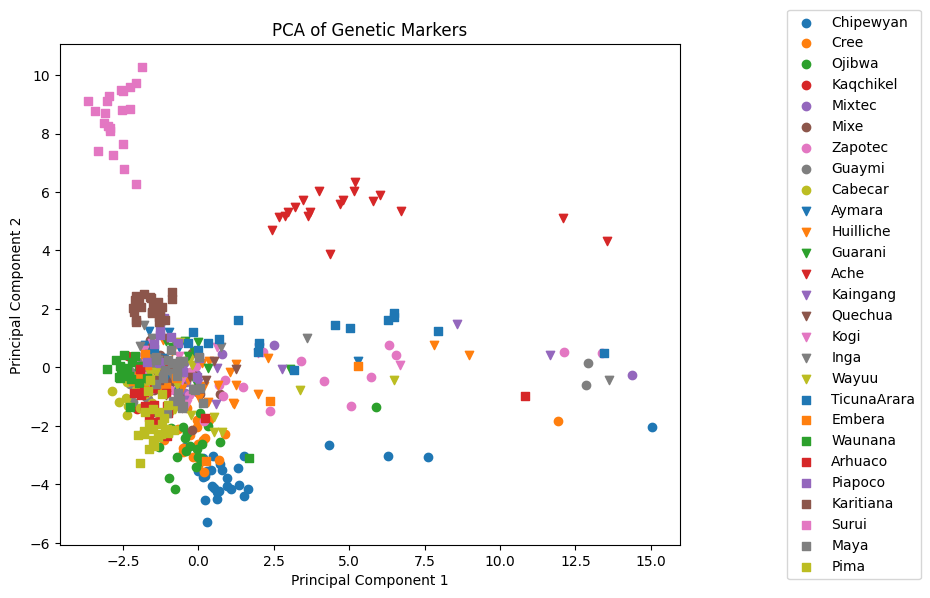

In [7]:
from sklearn.decomposition import PCA

pca1 = PCA()
X_pca1 = pca1.fit_transform(X)

#plot each of the first two principal components with the tribes colored differently
plt.figure(figsize=(8.0, 6.5))
for i, tribe in enumerate(gdf['Pop'].unique()):
    tribe_mask = (gdf['Pop'] == tribe).to_numpy()
    plt.scatter(X_pca1[tribe_mask, 0], X_pca1[tribe_mask, 1],
                marker=marker_list[i//9],
                color=colors_list[i%9], label=tribe)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.title('PCA of Genetic Markers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

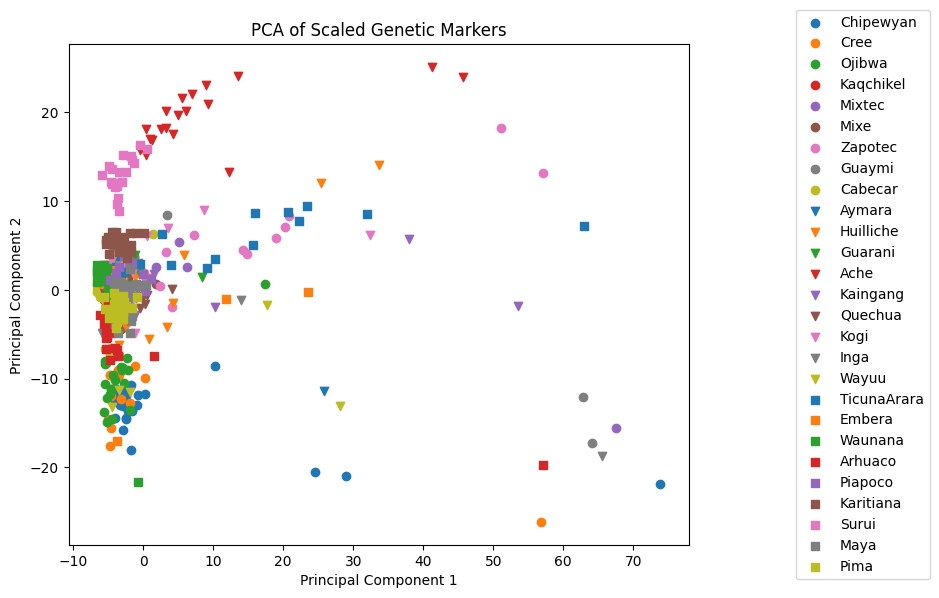

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit(X)
X_scaled = scaler.transform(X)

pca2 = PCA()
X_pca2 = pca2.fit_transform(X_scaled)
plt.figure(figsize=(8.0, 6.5))
for i, tribe in enumerate(gdf['Pop'].unique()):
    tribe_mask = (gdf['Pop'] == tribe).to_numpy()
    plt.scatter(X_pca2[tribe_mask, 0], X_pca2[tribe_mask, 1],
                marker=marker_list[i//9],
                color=colors_list[i%9], label=tribe)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.title('PCA of Scaled Genetic Markers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

We can see that the range of our display is much wider for the standardized PCA.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Scaling is essential because it standardizes marker weights, preventing high-frequency alleles from dominating the analysis. This "democratizes" the data, allowing PCA to reveal the true underlying population structure and much clearer genetic stratification. This statement needs to be qualified, as we also observe that some clusters are much more spread out.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

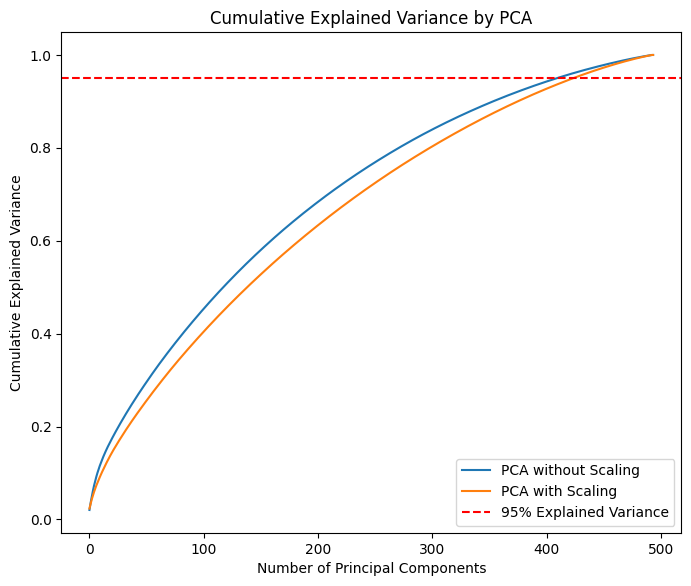

Variance for PCA with 2 components (without scaling): 0.0357
Variance for PCA with 2 components (with scaling): 0.0339
Number of components needed to explain 95% variance (without scaling): 410
Number of components needed to explain 95% variance (with scaling): 425


In [9]:
cumulative_variance_1 = np.cumsum(pca1.explained_variance_ratio_)
cumulative_variance_2 = np.cumsum(pca2.explained_variance_ratio_)
plt.figure(figsize=(8.0, 6.5))
plt.plot(cumulative_variance_1, label='PCA without Scaling')
plt.plot(cumulative_variance_2, label='PCA with Scaling')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA')
plt.legend()
plt.show()

print(f"Variance for PCA with 2 components (without scaling): {cumulative_variance_1[1]:.4f}")
print(f"Variance for PCA with 2 components (with scaling): {cumulative_variance_2[1]:.4f}")

print("Number of components needed to explain 95% variance (without scaling):", np.argmax(cumulative_variance_1 >= 0.95) + 1)
print("Number of components needed to explain 95% variance (with scaling):", np.argmax(cumulative_variance_2 >= 0.95) + 1)

We need 425 principal components to account for $95$% of the variance, which seems to be a good threshold for studying our population

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

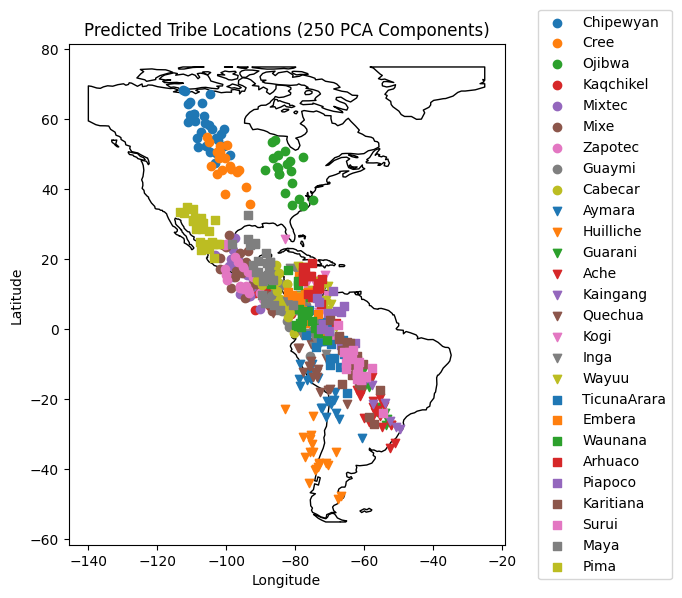

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

# PCA + linear regression
X_pca = PCA(n_components=250).fit_transform(X)
y = df[['lat', 'long']]
model = LinearRegression().fit(X_pca, y)
predictions = model.predict(X_pca) # predicted latitudes and longitudes

# plotting
fig, ax = plt.subplots(figsize=(8.0, 6.5))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    # predictions[:, 1] is longitude, predictions[:, 0] is latitude
    ax.scatter(predictions[mask, 1], predictions[mask, 0],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribe Locations (250 PCA Components)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

**Answer (4a):** The predicted map successfully reconstructs the broad geographic distribution of the tribes, showing that genetic markers are strong predictors of latitude and longitude. However, this map provides a highly optimistic view of the model's performance. Since the PCA and the linear regression were both fitted and evaluated on the same dataset, we are observing the "training error" rather than the "generalization error".  
Given that we use 250 principal components for only 494 individuals, the model is likely overfitting. It has enough degrees of freedom to "memorize" the specific coordinates of individuals in the database. Consequently, the ability to find the geographical origin of individuals outside the database would likely be much worse than what this map suggests. To obtain a realistic estimate, a cross-validation procedure  is mandatory.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [11]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

# radians conversion
y_rad = np.radians(y)
pred_rad = np.radians(predictions)

# haversine distances multiplied by earth's radius to get distances in km
dists = haversine_distances(y_rad, pred_rad).diagonal() * 6371
mean_error = dists.mean()

print(f"Mean error: {mean_error:.2f} km")

Mean error: 636.00 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates.

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**Answer :** principle of cross validation consists of keeping a part of the data set as a test set. This part won't be used to train the model. To be clearer, we split the data set into k "folds" (here k=10), then we train the model over k-1 of them. Then, we test the model with the remaining subset. The method is repeated k times (one for each fold). The performance of the model is the mean of each performance.

This procedure is useful when building a predictive model because it allows us to verify the model without overfitting.

If we are working with samples that are not i.i.d., we use "group" methods. To test the model, we need to make sure that all of the samples in the validation fold are not represented in the training folds. The following methods can be used : Group K-Fold, Stratified Group K-Fold, Leave One Group Out, Leave P Groups Out, Group Shuffle Split. Many of these methods work in the same way as the methods used for one sample, except here we use groups of data not iid.


**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

**Answer :** given the structure of the dataset, we will use a group method. Indeed, the data are not iid. We can see that by looking at the tribes as subjects, and each individuals as samples taken from those tribes. Hence, we can make groups by tribes. Then, we'll train the model so that it can find the geographical position of individuals from tribes that it did not learn from, using only the biological markers. Since we already know that we want to do 10 folds and that we are doing a regression (no stratification) , we can use the "Group K-Fold" method.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold



def meanerror(f, n, X, y):
  scaler = StandardScaler()
  pca = PCA(n_components=n)
  lr = LinearRegression()
  est=make_pipeline(scaler, pca, lr)

  cv = GroupKFold(n_splits=f)
  scores_test = []
  scores_train = []

  for train_index, test_index in cv.split(X, y, groups=tribes):
    X_train, y_train = X[train_index], y.iloc[train_index]
    X_test, y_test = X[test_index], y.iloc[test_index]
    est.fit(X_train, y_train)
    y_rad_test = np.radians(y_test)
    y_rad_train = np.radians(y_train)
    pred_rad_test = np.radians(est.predict(X_test))
    pred_rad_train = np.radians(est.predict(X_train))
    dists_test = haversine_distances(y_rad_test, pred_rad_test).diagonal() * 6371
    dists_train = haversine_distances(y_rad_train, pred_rad_train).diagonal() * 6371
    scores_test.append(dists_test.mean())
    scores_train.append(dists_train.mean())
  return (np.mean(scores_test), np.mean(scores_train))

meanerror(10, 4, X, y)

(np.float64(2486.484682637963), np.float64(1907.8143346899444))

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [13]:
comp = np.arange(2,440, 10)
(min_er_test,min_er_train) = meanerror(10, 2, X, y)
n_min_test=2
n_min_train=2
test=[]
train=[]

for n in comp:
  (er_test,er_train) = meanerror(10, n, X, y)
  test.append(er_test)
  train.append(er_train)
  print("n = ", n, " er test = ", er_test," er train = ", er_train, "\n")
  if er_test < min_er_test:
    min_er_test = er_test
    n_min_test = n
  if er_train < min_er_train:
    min_er_train = er_train
    n_min_train = n
print("nMin_test =", n_min_test, "er_min test=", min_er_test, "\n")
print("nMin_train =", n_min_train, "er_mi train=", min_er_train)



n =  2  er test =  2543.5396742136654  er train =  2041.5542734419723 

n =  12  er test =  2398.792233040584  er train =  1425.5149295768283 

n =  22  er test =  2332.910499754028  er train =  1237.5153772655394 

n =  32  er test =  2285.1687030660382  er train =  1060.0460938842593 

n =  42  er test =  2263.498150364912  er train =  973.233731566296 

n =  52  er test =  2236.5070602103065  er train =  940.6583165969435 

n =  62  er test =  2221.0612882457976  er train =  892.8347557891695 

n =  72  er test =  2228.126656560914  er train =  849.3211348940655 

n =  82  er test =  2197.262753151568  er train =  821.2942788985434 

n =  92  er test =  2208.0406135518606  er train =  787.3801145551688 

n =  102  er test =  2176.550600669573  er train =  762.9433714661434 

n =  112  er test =  2182.2011480321175  er train =  733.7650343654363 

n =  122  er test =  2173.9993652917087  er train =  708.5561975640917 

n =  132  er test =  2173.4413254851916  er train =  690.85494731

2176.550600669573


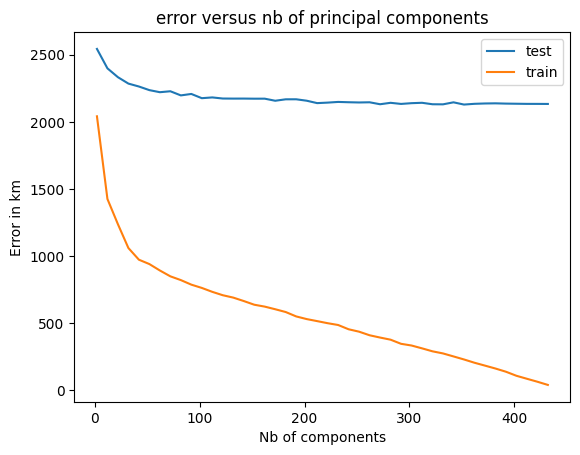

In [14]:
plt.plot(comp, test, label="test")
plt.plot(comp, train, label="train")

print(test[10])


plt.title('error versus nb of principal components')
plt.xlabel('Nb of components')
plt.ylabel('Error in km')
plt.legend()
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

**Comments:** the previous question leads us to keep the model corresponding to n = 52 (more or less) may be the most efficient. The test error remains stagnant for more components while the training error keeps on reducing. Even though this is not the point where the error is at its lowest, taking a higher number of components would be risking overfitting the model.
The prediction error is of 2260 km, while the training error is of 970km. The testing error is about 2.5 times higher, which means there still may be some overfitting. Geographically, taking into account the size of America (approximately 14000km), the error is quite significant , but it shows that the model does better than juste predicting random points (the error would rise higher) : the model is still able to reduce the error despite some overfitting of the data.

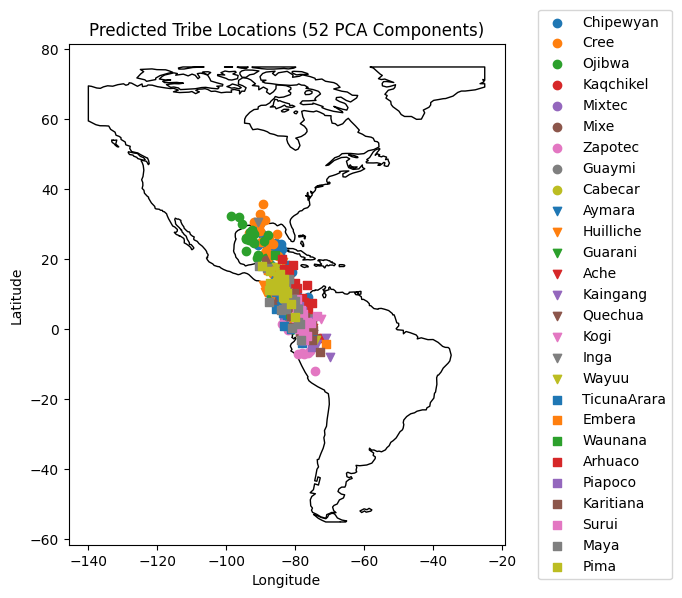

In [15]:
#model
scaler = StandardScaler()
pca = PCA(n_components=52)
lr = LinearRegression()
est=make_pipeline(scaler, pca, lr)
cv = GroupKFold(n_splits=10)
predictions=np.zeros_like(y)


for train_index, test_index in cv.split(X, y, groups=tribes):
  X_train, y_train = X[train_index], y.iloc[train_index]
  X_test, y_test = X[test_index], y.iloc[test_index]
  est.fit(X_train, y_train)
  #adding only the data predicted when they are not used to train the model
  predictions[test_index] = est.predict(X_test)


# plotting
fig, ax = plt.subplots(figsize=(8.0, 6.5))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    # predictions[:, 1] is longitude, predictions[:, 0] is latitude
    ax.scatter(predictions[mask, 1], predictions[mask, 0],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribe Locations (52 PCA Components)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


**Comments:** map shows that the model does no predict randomly the results : people from the same tribes (who share similar biological markers) are close together on the map, which is one of the thing we were aiming to. However, we see that the predicted value are close to the center of the map : the model is trying to reduce the potential error it is making. This is the best way to avoid a huge mistake. However, it leads to a map where all the predicted data are more or less placed on the same spots. This map shows the reel performance of the model and leads us to believe that the modele of ex 4 was heavily overfitting.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In [16]:
df['error_km'] = dists
print("Top 5 best predicted tribes (km):")
print(df.groupby('Pop')['error_km'].mean().sort_values().head(5))

print("\nTop 5 worst predicted tribes (km):")
print(df.groupby('Pop')['error_km'].mean().sort_values().tail(5))

Top 5 best predicted tribes (km):
Pop
Surui     480.727543
Pima      480.955185
Wayuu     504.070529
Ache      541.791373
Embera    566.212153
Name: error_km, dtype: float64

Top 5 worst predicted tribes (km):
Pop
Guarani      744.795784
Huilliche    765.280089
Aymara       768.434905
Guaymi       789.311490
Kaqchikel    820.653470
Name: error_km, dtype: float64


#### Model performance and overfitting

Through cross-validation, we identified 52 principal components as the optimal complexity for this PCR model. However, there is a massive gap between the training error and the validation error. This clearly indicates overfitting: with 52 factors for only about 500 individuals, the model isn't just learning geography; it is memorizing the specific genetic noise of the tribes in the database.

#### Limitations and geographic reality

- Model overfitting: As demonstrated in our cross-validation analysis, models that include too many components tend to overfit the training data, capturing patterns that do not generalize effectively to new populations.

- A linear model seems to have some problems to fully capture the complexity of genetical patterns

#### Proposed improvement:

To significantly improve accuracy, we should replace PCR with Non-Linear Models: random forests, or neural networks might better capture complex relationships between genetic markers and geography.

#### Final Word

Our model can hardly reconstruct a rough map of the Americas from DNA, it acts more as an anthropological tool than a precise GPS. The high error rate on unseen data shows that genetic identity is complex and that simple linear models cannot fully resolve it.